# Imports

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [3]:
data = pd.read_csv('IRIS.csv')

# EDA

In [11]:
data.head(3)

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa


In [5]:
data.shape

(150, 5)

In [6]:
data['species'].value_counts()

species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

Perfectly balanced dataset

In [7]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    str    
dtypes: float64(4), str(1)
memory usage: 6.0 KB


- No null values
- Target feature is a categorical variable, need to encode it

In [8]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
sepal_length,150.0,5.843333,0.828066,4.3,5.1,5.80,6.4,7.9
sepal_width,150.0,3.054000,0.433594,2.0,2.8,3.00,3.3,4.4
petal_length,150.0,3.758667,1.764420,1.0,1.6,4.35,5.1,6.9
petal_width,150.0,1.198667,0.763161,0.1,0.3,1.30,1.8,2.5


In [13]:
# Use LabelEncoder() for the target feature
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

data['species'] = le.fit_transform(data['species'])

data.head(3)

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0


In [14]:
data['species'].value_counts()

species
0    50
1    50
2    50
Name: count, dtype: int64

Text(0.5, 1.0, 'Correlation between the variables')

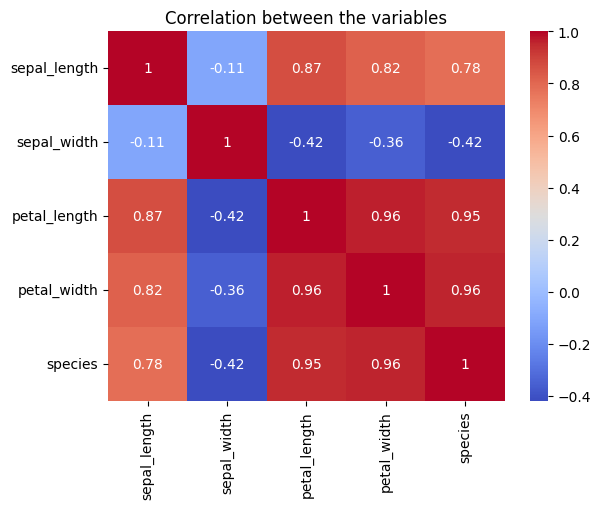

In [18]:
# PLOT HEATMAP FOR THE CORRELATION

data_corr = data.corr()

sns.heatmap(data=data_corr, annot=True, cmap='coolwarm')
plt.title('Correlation between the variables')

Although there is multicollinearity between the petal_length and petal_width, in KNN model it is not as critical to the algorithm as say a Logistic Regression model where would need to treat it. For the purposes of this model, I am going to leave it in.

We can also see that the petal length and width are the highest predictors of the species.

Text(0.5, 1.0, 'Species Pair Plots')

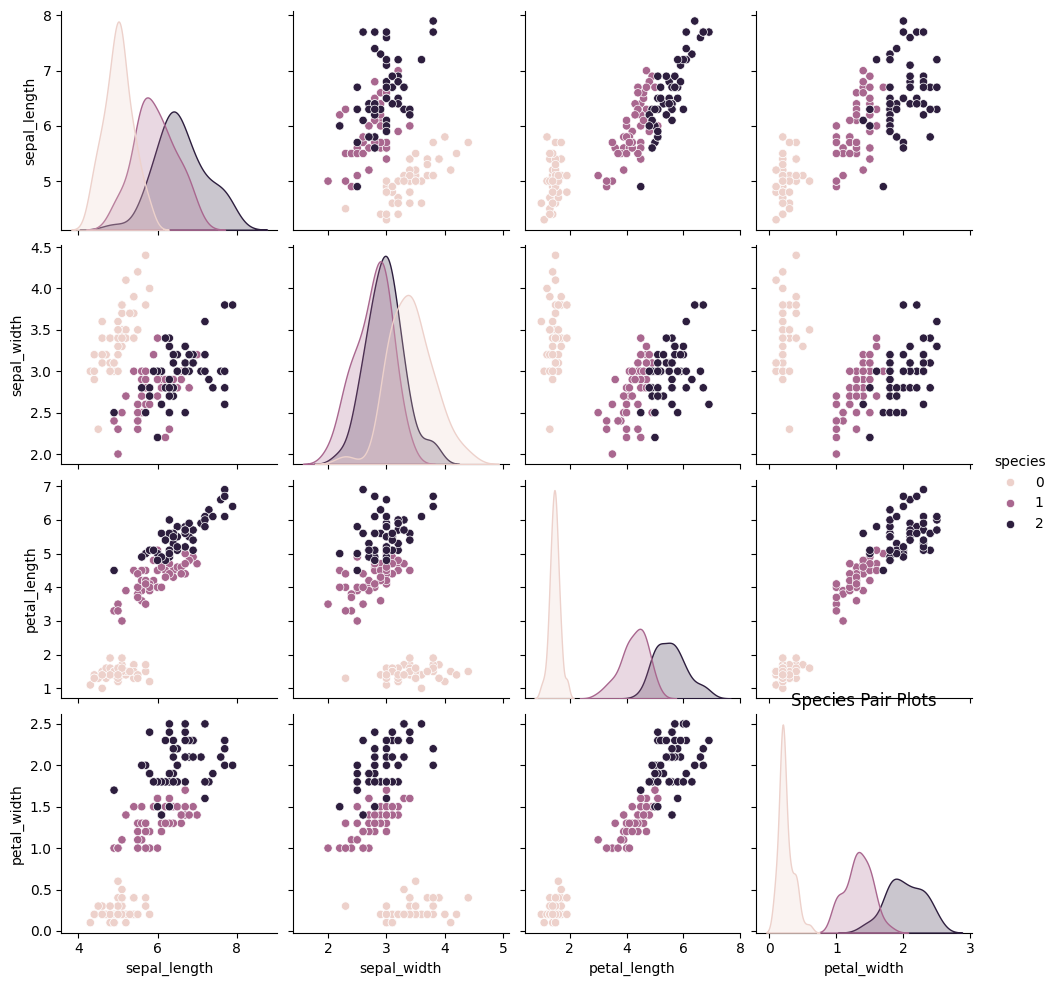

In [20]:
# PAIRPLOT FOR THE TARGET FEATURE TO UNDERSTAND DISTANCES BEFORE KNN

sns.pairplot(data,hue='species')
plt.title('Species Pair Plots')

From the pairplot, we can tell easily that the petal length and width give the best prediciton of the species class because of the low overlap in colors

The sepal length and width do a pretty good job, but there is some confusion in the plots, mostly for the species 1 and 2 classificaitons

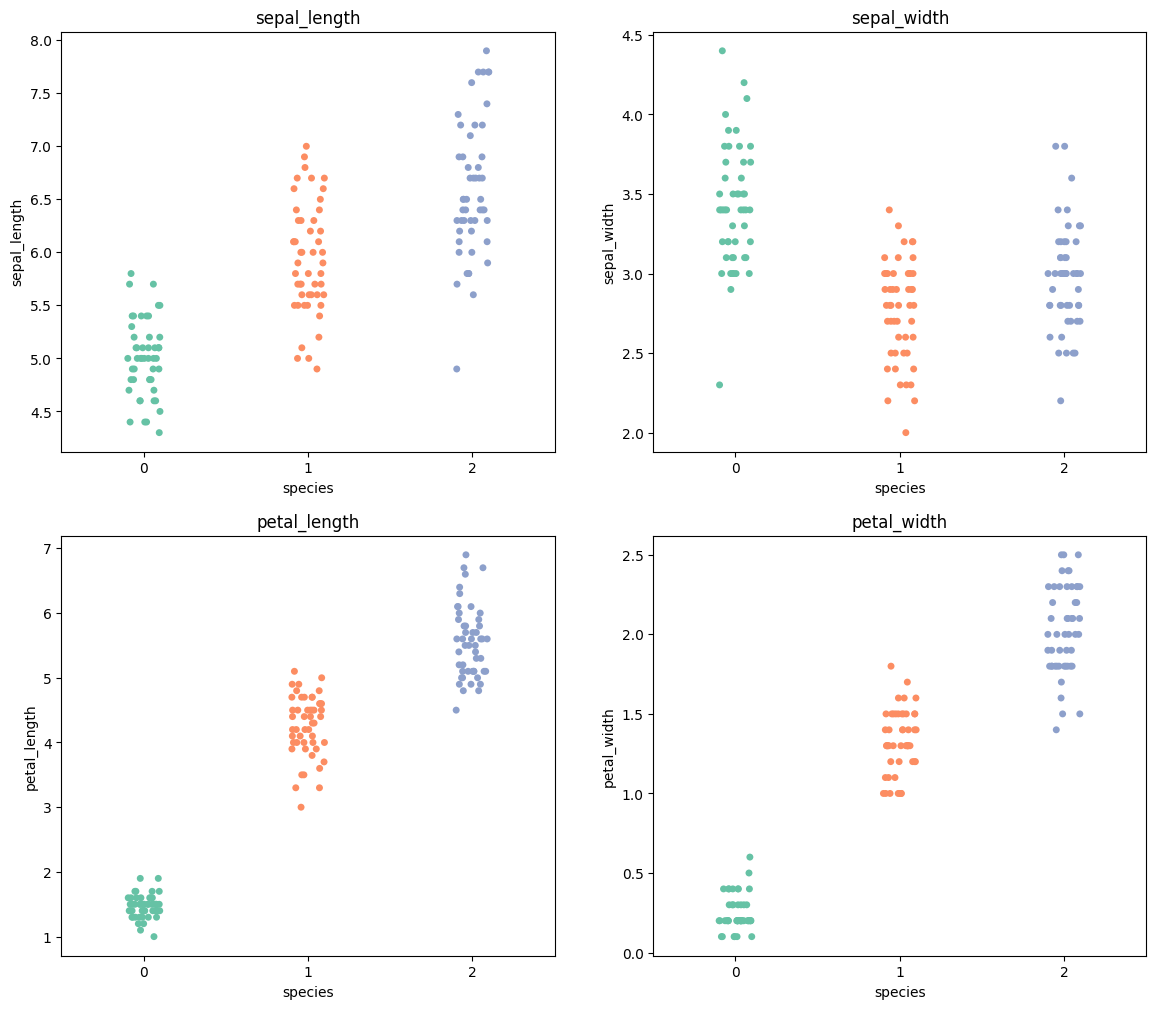

In [33]:
# BOX PLOTS FOR EACH FEATURE WITH THE SPECIES

fig, axes = plt.subplots(2, 2, figsize=(14,12))

features = [col for col in data.columns if col != 'species'] # Set up features for the subplots
axes = axes.flatten() # Allows for looping
for i, feature in enumerate(features):
    sns.stripplot(x='species', y=feature, data=data, palette='Set2', ax=axes[i])
    axes[i].set_title(feature) # .set_title() operates at the axis level, where .title() would be the plot level

The stripplots above also clearly show the separation of species with the petal length and width

# Split Dataset

In [49]:
from sklearn.model_selection import train_test_split

X = data.iloc[:, :-1]
y = data.iloc[:, -1]

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(112, 4)
(38, 4)
(112,)
(38,)


# Pipeline: Scaling and Hyperparameter Tuning at the same time to avoid data leakage 

In [59]:
# Import necessary packages
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from sklearn.preprocessing import StandardScaler

# Define the Pipeline
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier())
])

# Define Parameter Grid
param_grid = {
    'knn__n_neighbors': [3, 5, 7, 9, 11],
    'knn__weights':     ['uniform', 'distance'],
    'knn__algorithm':   ['auto', 'ball_tree', 'kd_tree', 'brute'],
    'knn__leaf_size':   [20, 30, 40, 50, 60]
}

grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    verbose=1,
    refit=True          # automatically refits best model on full X_train=
)

# Fit on Raw unscaled X_train
grid_search.fit(X_train, y_train)

# Inspect the results
print(f'Best Parameters : {grid_search.best_params_}')
print(f'Best CV Score   : {grid_search.best_score_:.4f}')

# Predict
train_pred = grid_search.predict(X_train)
test_pred = grid_search.predict(X_test)
train_proba = grid_search.predict_proba(X_train)
test_proba = grid_search.predict_proba(X_test)

# Evaluate
print('\nTRAINING SCORES:')
print(f'Accuracy  : {accuracy_score(y_train, train_pred):.4f}')
print(f'F1        : {f1_score(y_train, train_pred, average="weighted"):.4f}')
print(f'ROC-AUC   : {roc_auc_score(y_train, train_proba, multi_class="ovr", average="macro"):.4f}')

print('\nTESTING SCORES:')
print(f'Accuracy  : {accuracy_score(y_test, test_pred):.4f}')
print(f'F1        : {f1_score(y_test, test_pred, average="weighted"):.4f}')
print(f'ROC-AUC   : {roc_auc_score(y_test, test_proba, multi_class="ovr", average="macro"):.4f}')

Fitting 5 folds for each of 200 candidates, totalling 1000 fits
Best Parameters : {'knn__algorithm': 'auto', 'knn__leaf_size': 20, 'knn__n_neighbors': 9, 'knn__weights': 'distance'}
Best CV Score   : 0.9549

TRAINING SCORES:
Accuracy  : 1.0000
F1        : 1.0000
ROC-AUC   : 1.0000

TESTING SCORES:
Accuracy  : 1.0000
F1        : 1.0000
ROC-AUC   : 1.0000


In [51]:
help(KNeighborsClassifier())

Help on KNeighborsClassifier in module sklearn.neighbors._classification object:

class KNeighborsClassifier(sklearn.neighbors._base.KNeighborsMixin, sklearn.base.ClassifierMixin, sklearn.neighbors._base.NeighborsBase)
 |  KNeighborsClassifier(
 |      n_neighbors=5,
 |      *,
 |      weights='uniform',
 |      algorithm='auto',
 |      leaf_size=30,
 |      p=2,
 |      metric='minkowski',
 |      metric_params=None,
 |      n_jobs=None
 |  )
 |
 |  Classifier implementing the k-nearest neighbors vote.
 |
 |  Read more in the :ref:`User Guide <classification>`.
 |
 |  Parameters
 |  ----------
 |  n_neighbors : int, default=5
 |      Number of neighbors to use by default for :meth:`kneighbors` queries.
 |
 |  weights : {'uniform', 'distance'}, callable or None, default='uniform'
 |      Weight function used in prediction.  Possible values:
 |
 |      - 'uniform' : uniform weights.  All points in each neighborhood
 |        are weighted equally.
 |      - 'distance' : weight points by

In [60]:
# Run multiple splits to see if 1.0 is consistent or lucky
from sklearn.model_selection import cross_val_score

scores = cross_val_score(grid_search.best_estimator_, X, y, cv=10, scoring='accuracy')
print(scores)
print(f'Mean: {scores.mean():.4f}  Std: {scores.std():.4f}')

[1.         0.93333333 1.         0.93333333 0.93333333 1.
 0.86666667 1.         1.         1.        ]
Mean: 0.9667  Std: 0.0447


We can see that the average score for the 10 different splits, which is a good score